# Modelado por cluster con optimización de hiperparámetros

Este notebook ajusta un modelo por cada cluster climático-edáfico. Para cada cluster se
optimizan tres modelos: **XGBoost**, **LightGBM** y una **red neuronal** (MLP). Se guarda la
grilla completa de combinaciones de cada modelo, con métricas en train, validación y test,
para poder elegir el mejor modelo de forma manual.

El enfoque atiende un problema observado en el modelado global: una diferencia grande entre
train/validación y test, con R² bajo y errores altos en test. Para reducir ese sobreajuste se
usan rangos de regularización más amplios, validación cruzada espacial por condado, y se
registra explícitamente el **gap train−test** de cada combinación, que es la señal directa de
sobreajuste.

Se trabaja con dos métricas: **R²** y **WMAPE**.

## Librerías

In [2]:
import polars as pl
import pandas as pd
import numpy as np

# Modelos
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import optuna

# Utilidades
import time
import os
import json
import joblib
import matplotlib.pyplot as plt
import matplotlib as mpl

optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\lesli\Documents\TFM\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuración

`N_TRIALS` controla cuántas combinaciones prueba Optuna por modelo y por cluster. La red
neuronal es la más lenta, por eso tiene su propio valor. Con 5 clusters y 3 modelos, el total
de ajustes es considerable, así que conviene empezar con pocos trials para probar el flujo y
luego subirlos.

In [3]:
RUTA_DATOS = '../Data/'
MODELS_DIR = '../models/'
OUTPUT_DIR = 'C:/Users/lesli/Documents/TFM/notebooks/ML_outputs'
FIG_DIR    = os.path.join(OUTPUT_DIR, 'figuras_latex')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Número de combinaciones por modelo (subir cuando el flujo funcione)
N_TRIALS_XGB = 25
N_TRIALS_LGB = 25
N_TRIALS_NN  = 15

features_base = [
    "tmax", "tmin", "ppt",                       # clima (= fórmula)
    "ph1to1h2o_r", "awc_r",                      # suelo de la fórmula
    "profundidad_efectiva_cm",                   # AÑADIR: la fórmula la usa
    "claytotal_r", "dbthirdbar_r",               # texturas (información de suelo)
    "sandtotal_r", "silttotal_r",
    # vpdmean QUITADO: baja importancia + problema de homologación futura
]


etiquetas_cluster = {
    0: "Montaña / clima frío",
    1: "Zona templada húmeda",
    2: "Valle cálido — suelo arenoso",
    3: "Valle cálido — suelo arcilloso",
    4: "Desierto árido"
}

# Configuración de matplotlib para figuras en PDF vectorial (LaTeX)
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "serif", "font.size": 10,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 8, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "figure.dpi": 140, "savefig.dpi": 300, "savefig.bbox": "tight",
})

def guardar_figura(fig, nombre):
    ruta = os.path.join(FIG_DIR, f"{nombre}.pdf")
    fig.savefig(ruta, format="pdf", bbox_inches="tight")
    print(f"Figura guardada: {ruta}")

## Métricas: R² y WMAPE

Se usan las mismas dos métricas del notebook anterior. El WMAPE mide el error absoluto total
como porcentaje del valor real acumulado y es estable aunque el IAI tome valores pequeños:

$$ \text{WMAPE} = \frac{\sum_i |y_i - \hat{y}_i|}{\sum_i |y_i|} \times 100 $$

In [4]:
def wmape(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else 100.0 * np.sum(np.abs(y_true - y_pred)) / denom

def calcular_metricas(y_true, y_pred):
    return {
        "r2":    r2_score(y_true, y_pred),
        "wmape": wmape(y_true, y_pred),
        "rmse":  np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae":   mean_absolute_error(y_true, y_pred),
    }

## Carga del dataset con clusters

In [5]:
df = pl.read_parquet(os.path.join(RUTA_DATOS, "df_cluster.parquet"))
clusters = sorted(df["cluster"].unique().to_list())
print(f"Dataset: {df.shape[0]:,} filas | Clusters: {clusters}")
print(df.group_by("cluster").len().sort("cluster"))

Dataset: 633,904 filas | Clusters: [0, 1, 2, 3, 4]
shape: (5, 2)
┌─────────┬────────┐
│ cluster ┆ len    │
│ ---     ┆ ---    │
│ i32     ┆ u32    │
╞═════════╪════════╡
│ 0       ┆ 45954  │
│ 1       ┆ 140815 │
│ 2       ┆ 210097 │
│ 3       ┆ 195672 │
│ 4       ┆ 41366  │
└─────────┴────────┘


## Split geográfico por cluster

Se mantiene el split geográfico por condado dentro de cada cluster. Asignar condados completos
a train/val/test evita que parcelas casi idénticas queden en train y test, que era una de las
causas de las métricas infladas en train frente a test.

In [6]:
def split_geografico_cluster(df_cluster, prop_train=0.70, prop_val=0.10, seed=42):
    """Asigna condados completos a train/val/test respetando proporciones objetivo."""
    np.random.seed(seed)
    conteo = (df_cluster.group_by("county").len()
              .sort("len", descending=True).to_pandas())
    total = conteo["len"].sum()
    objetivo = {"train": prop_train*total, "val": prop_val*total,
                "test": (1-prop_train-prop_val)*total}
    acumulado = {"train": 0, "val": 0, "test": 0}
    asignacion = {}
    for _, row in conteo.iterrows():
        deficit = {k: (objetivo[k]-acumulado[k])/objetivo[k]
                   for k in objetivo if objetivo[k] > 0}
        destino = max(deficit, key=deficit.get)
        asignacion[row["county"]] = destino
        acumulado[destino] += row["len"]
    df_split = df_cluster.with_columns(
        pl.col("county").replace(asignacion).alias("split"))
    return df_split, asignacion, acumulado, total

## Preparación de datos por cluster

Esta función devuelve las matrices X/y de train, validación y test de un cluster, junto con el
array de condados de train (necesario para la validación cruzada espacial) y la lista de
features. El one-hot del cultivo se hace dentro del cluster.

In [7]:
def preparar_cluster(c):
    df_c = df.filter(pl.col("cluster") == c)
    df_c_split, asignacion, acum, total = split_geografico_cluster(df_c)
    df_c_oh = df_c_split.to_dummies(columns=["crop_name"])
    cols_cultivo = sorted([col for col in df_c_oh.columns if col.startswith("crop_name_")])
    features_modelo = features_base + cols_cultivo

    def get_xy(split_name):
        sub = df_c_oh.filter(pl.col("split") == split_name)
        return (sub.select(features_modelo).to_numpy(),
                sub.select("IAI").to_numpy().ravel(),
                sub.select("county").to_numpy().ravel())

    X_tr, y_tr, cond_tr = get_xy("train")
    X_v,  y_v,  _       = get_xy("val")
    X_te, y_te, _       = get_xy("test")
    return {
        "X_tr": X_tr, "y_tr": y_tr, "cond_tr": cond_tr,
        "X_v": X_v, "y_v": y_v, "X_te": X_te, "y_te": y_te,
        "features": features_modelo,
        "n_condados_tr": len(np.unique(cond_tr)),
    }

## Construcción y ajuste de modelos

Se centraliza en dos funciones la creación y el ajuste de cada tipo de modelo, para que la
búsqueda de hiperparámetros sea idéntica en los tres casos. La red neuronal se arma como un
`Pipeline` con `StandardScaler`, porque el MLP sí necesita escalado (a diferencia de los
árboles). El escalado queda dentro del pipeline, así que la predicción lo aplica sola.

In [8]:
def construir_modelo(tipo, params):
    if tipo == "XGBoost":
        return xgb.XGBRegressor(**params)
    if tipo == "LightGBM":
        return lgb.LGBMRegressor(**params)
    if tipo == "RedNeuronal":
        return make_pipeline(StandardScaler(), MLPRegressor(**params))
    raise ValueError(tipo)

def ajustar_modelo(tipo, modelo, X_tr, y_tr, X_v, y_v):
    if tipo == "XGBoost":
        modelo.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
    elif tipo == "LightGBM":
        modelo.fit(X_tr, y_tr, eval_set=[(X_v, y_v)],
                   callbacks=[lgb.early_stopping(30, verbose=False)])
    else:  # RedNeuronal: early stopping interno del MLP
        modelo.fit(X_tr, y_tr)
    return modelo

## Espacios de búsqueda

Los rangos favorecen modelos más regularizados que en el notebook global. En los árboles se
limita la profundidad y se suben los mínimos de muestras por hoja; en la red se usa
regularización L2 (`alpha`) y early stopping interno. La idea es reducir el gap train−test.

In [9]:
def sugerir_xgb(trial):
    return {
        "n_estimators":     trial.suggest_categorical("n_estimators", [200, 400, 600]),
        "max_depth":        trial.suggest_categorical("max_depth", [3, 4, 6]),
        "learning_rate":    trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1]),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 30),
        "random_state": 42, "n_jobs": -1, "early_stopping_rounds": 30,
    }

def sugerir_lgb(trial):
    return {
        "n_estimators":      trial.suggest_categorical("n_estimators", [300, 500, 800]),
        "max_depth":         trial.suggest_categorical("max_depth", [4, 6, 10]),
        "num_leaves":        trial.suggest_categorical("num_leaves", [20, 50, 100]),
        "learning_rate":     trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1]),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 150),
        "random_state": 42, "n_jobs": -1, "verbose": -1,
    }

def sugerir_nn(trial):
    arqs = {"64-32": (64, 32), "128-64": (128, 64), "128-64-32": (128, 64, 32)}
    nombre_arq = trial.suggest_categorical("arquitectura", list(arqs.keys()))
    return {
        "hidden_layer_sizes": arqs[nombre_arq],
        "alpha":              trial.suggest_float("alpha", 1e-5, 1e-1, log=True),
        "learning_rate_init": trial.suggest_float("learning_rate_init", 1e-4, 1e-2, log=True),
        "activation": "relu", "solver": "adam", "max_iter": 300,
        "early_stopping": True, "validation_fraction": 0.1,
        "n_iter_no_change": 15, "random_state": 42,
    }

SUGERIR = {"XGBoost": sugerir_xgb, "LightGBM": sugerir_lgb, "RedNeuronal": sugerir_nn}

## Registro de la grilla

Cada combinación probada se guarda en `registro_grid` con sus métricas en train, validación y
test, el WMAPE de validación cruzada, el gap train−test y el tiempo de ajuste. Los parámetros
originales se guardan aparte en `registro_params` para poder reentrenar el modelo elegido.

In [10]:
registro_grid = []
registro_params = {}   # (cluster, tipo, trial) -> params

def registrar(c, tipo, trial_num, params, modelo_full, cv_wmape, t_fit, datos):
    m_tr = calcular_metricas(datos["y_tr"], modelo_full.predict(datos["X_tr"]))
    m_v  = calcular_metricas(datos["y_v"],  modelo_full.predict(datos["X_v"]))
    m_te = calcular_metricas(datos["y_te"], modelo_full.predict(datos["X_te"]))
    fila = {
        "cluster": c, "etiqueta": etiquetas_cluster.get(c, str(c)),
        "modelo": tipo, "trial": trial_num, "cv_wmape_val": cv_wmape,
        "r2_train": m_tr["r2"], "r2_val": m_v["r2"], "r2_test": m_te["r2"],
        "wmape_train": m_tr["wmape"], "wmape_val": m_v["wmape"], "wmape_test": m_te["wmape"],
        "gap_r2_train_test": m_tr["r2"] - m_te["r2"],
        "gap_r2_train_val":  m_tr["r2"] - m_v["r2"],
        "t_fit_full_s": t_fit,
    }
    fila.update({f"param_{k}": (str(v) if isinstance(v, tuple) else v)
                 for k, v in params.items()})
    registro_grid.append(fila)
    registro_params[(c, tipo, trial_num)] = params

## Búsqueda por cluster y por modelo

Para cada cluster se optimizan los tres modelos. El criterio es el **WMAPE de validación
cruzada espacial** (se minimiza). La CV usa `GroupKFold` sobre los condados de train, con
tantos folds como condados haya disponibles (máximo 5). Cada combinación se reentrena además
sobre todo el train para registrar sus métricas en los tres conjuntos.

In [11]:
def hacer_objetivo(c, tipo, datos):
    X_tr, y_tr, cond_tr = datos["X_tr"], datos["y_tr"], datos["cond_tr"]
    X_v, y_v = datos["X_v"], datos["y_v"]
    n_folds = min(5, datos["n_condados_tr"])

    def objetivo(trial):
        params = SUGERIR[tipo](trial)
        # CV espacial (si hay al menos 2 condados)
        if n_folds >= 2:
            gkf = GroupKFold(n_splits=n_folds)
            wms = []
            for idx_tr, idx_val in gkf.split(X_tr, y_tr, groups=cond_tr):
                m = construir_modelo(tipo, params)
                m = ajustar_modelo(tipo, m, X_tr[idx_tr], y_tr[idx_tr],
                                   X_tr[idx_val], y_tr[idx_val])
                wms.append(wmape(y_tr[idx_val], m.predict(X_tr[idx_val])))
            cv_wmape = float(np.mean(wms))
        else:
            cv_wmape = np.nan

        # Modelo sobre todo el train para registrar train/val/test
        t0 = time.time()
        m_full = construir_modelo(tipo, params)
        m_full = ajustar_modelo(tipo, m_full, X_tr, y_tr, X_v, y_v)
        t_fit = time.time() - t0
        registrar(c, tipo, trial.number, params, m_full, cv_wmape, t_fit, datos)
        return cv_wmape if not np.isnan(cv_wmape) else registro_grid[-1]["wmape_val"]
    return objetivo

In [12]:
datos_cluster = {}
for c in clusters:
    datos = preparar_cluster(c)
    datos_cluster[c] = datos
    print(f"Cluster {c} ({etiquetas_cluster.get(c, c)}): "
          f"Train {len(datos['y_tr']):,} | Val {len(datos['y_v']):,} | "
          f"Test {len(datos['y_te']):,} | Condados train {datos['n_condados_tr']}")

Cluster 0 (Montaña / clima frío): Train 25,569 | Val 10,530 | Test 9,855 | Condados train 30
Cluster 1 (Zona templada húmeda): Train 97,165 | Val 15,886 | Test 27,764 | Condados train 43
Cluster 2 (Valle cálido — suelo arenoso): Train 136,181 | Val 32,884 | Test 41,032 | Condados train 48
Cluster 3 (Valle cálido — suelo arcilloso): Train 130,330 | Val 28,081 | Test 37,261 | Condados train 40
Cluster 4 (Desierto árido): Train 27,632 | Val 10,991 | Test 2,743 | Condados train 1


In [13]:
def optimizar_por_clusters(tipo, n_trials):
    """Optimiza un único modelo en todos los clusters y registra la grilla.
    Se puede reejecutar sin duplicar: limpia primero los registros de ese modelo."""
    global registro_grid
    registro_grid = [f for f in registro_grid if f["modelo"] != tipo]
    for k in [key for key in list(registro_params) if key[1] == tipo]:
        registro_params.pop(k)

    for c in clusters:
        datos = datos_cluster[c]
        if len(datos["y_v"]) == 0 or len(datos["y_te"]) == 0:
            print(f"Cluster {c}: sin val o test suficiente — se omite.")
            continue
        t0 = time.time()
        estudio = optuna.create_study(direction="minimize",
                                      study_name=f"{tipo}_cluster{c}")
        estudio.optimize(hacer_objetivo(c, tipo, datos),
                         n_trials=n_trials, show_progress_bar=False)
        print(f"Cluster {c} ({etiquetas_cluster.get(c, c)}): "
              f"mejor WMAPE CV {estudio.best_value:.3f}% | {time.time()-t0:.1f}s")

## XGBoost

In [14]:
optimizar_por_clusters("XGBoost", N_TRIALS_XGB)

Cluster 0 (Montaña / clima frío): mejor WMAPE CV 0.702% | 168.5s
Cluster 1 (Zona templada húmeda): mejor WMAPE CV 0.700% | 566.6s
Cluster 2 (Valle cálido — suelo arenoso): mejor WMAPE CV 0.822% | 964.4s
Cluster 3 (Valle cálido — suelo arcilloso): mejor WMAPE CV 0.509% | 925.1s
Cluster 4 (Desierto árido): mejor WMAPE CV 0.347% | 40.4s


## LightGBM

In [15]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names",
    category=UserWarning,
)

In [16]:
optimizar_por_clusters("LightGBM", N_TRIALS_LGB)

Cluster 0 (Montaña / clima frío): mejor WMAPE CV 0.784% | 144.3s
Cluster 1 (Zona templada húmeda): mejor WMAPE CV 0.548% | 916.8s
Cluster 2 (Valle cálido — suelo arenoso): mejor WMAPE CV 0.744% | 993.0s
Cluster 3 (Valle cálido — suelo arcilloso): mejor WMAPE CV 0.641% | 716.3s
Cluster 4 (Desierto árido): mejor WMAPE CV 0.452% | 53.2s


## Grilla de resultados

Se consolidan todas las combinaciones en un solo DataFrame ordenado por cluster, modelo y
WMAPE de validación cruzada. Esta tabla es la herramienta para elegir el mejor modelo de cada
cluster: permite comparar no solo el error de validación, sino también el gap train−test, que
indica qué tan bien generaliza cada combinación.

In [17]:
df_grid = pl.DataFrame(registro_grid)
cols_frente = ["cluster", "etiqueta", "modelo", "trial", "cv_wmape_val",
               "wmape_train", "wmape_val", "wmape_test",
               "r2_train", "r2_val", "r2_test",
               "gap_r2_train_test", "gap_r2_train_val", "t_fit_full_s"]
otras = [col for col in df_grid.columns if col not in cols_frente]
df_grid = df_grid.select(cols_frente + otras).sort(
    ["cluster", "modelo", "cv_wmape_val"])

print(f"Total de combinaciones registradas: {df_grid.shape[0]}")
with pl.Config(tbl_rows=20, tbl_cols=-1, fmt_str_lengths=60):
    print(df_grid.head(20))

Total de combinaciones registradas: 250
shape: (20, 25)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ clu ┆ eti ┆ mod ┆ tri ┆ cv_ ┆ wma ┆ wma ┆ wma ┆ r2_ ┆ r2_ ┆ r2_ ┆ gap ┆ gap ┆ t_f ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par ┆ par │
│ ste ┆ que ┆ elo ┆ al  ┆ wma ┆ pe_ ┆ pe_ ┆ pe_ ┆ tra ┆ val ┆ tes ┆ _r2 ┆ _r2 ┆ it_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ ┆ am_ │
│ r   ┆ ta  ┆ --- ┆ --- ┆ pe_ ┆ tra ┆ val ┆ tes ┆ in  ┆ --- ┆ t   ┆ _tr ┆ _tr ┆ ful ┆ n_e ┆ max ┆ lea ┆ sub ┆ col ┆ reg ┆ reg ┆ min ┆ ran ┆ n_j ┆ ear │
│ --- ┆ --- ┆ str ┆ i64 ┆ val ┆ in  ┆ --- ┆ t   ┆ --- ┆ f64 ┆ --- ┆ ain ┆ ain ┆ l_s ┆ sti ┆ _de ┆ rni ┆ sam ┆ sam ┆ _al ┆ _la ┆ _ch ┆ dom ┆ obs ┆ ly_ │
│ i64 ┆ str ┆     ┆     ┆ --- ┆ --- ┆ f64 ┆ --- ┆ f64 ┆     ┆ f64 ┆ _te ┆ _va ┆ --- ┆ mat ┆ pth ┆ ng_ ┆ ple ┆ ple ┆ pha ┆ mbd ┆ ild ┆ _st ┆ --- ┆ sto │
│     ┆     ┆     ┆     ┆ f64 ┆ 

## Exportar la grilla (CSV y Excel)

La grilla se guarda en CSV y en un Excel con una hoja por modelo, más una hoja de resumen con
la mejor combinación de cada modelo en cada cluster. Así queda todo el detalle disponible para
la decisión.

In [18]:
# CSV completo
df_grid.write_csv(os.path.join(OUTPUT_DIR, "grid_clusters_completo.csv"))

# Resumen: mejor combinación (menor WMAPE CV) por cluster y modelo
df_mejores = (df_grid.sort("cv_wmape_val")
              .group_by(["cluster", "etiqueta", "modelo"])
              .first()
              .sort(["cluster", "cv_wmape_val"]))

# Excel con una hoja por modelo + hoja de resumen
ruta_excel = os.path.join(OUTPUT_DIR, "grid_clusters.xlsx")
with pd.ExcelWriter(ruta_excel, engine="xlsxwriter") as writer:
    df_mejores.to_pandas().to_excel(writer, sheet_name="resumen_mejores", index=False)
    for tipo in df_grid["modelo"].unique().to_list():
        (df_grid.filter(pl.col("modelo") == tipo)
         .to_pandas().to_excel(writer, sheet_name=tipo, index=False))

print(f"CSV:   {os.path.join(OUTPUT_DIR, 'grid_clusters_completo.csv')}")
print(f"Excel: {ruta_excel}")
print("\nMejor combinación por cluster y modelo:")
with pl.Config(tbl_rows=-1, tbl_cols=-1):
    print(df_mejores.select(["cluster", "etiqueta", "modelo", "cv_wmape_val",
                             "wmape_test", "r2_test", "gap_r2_train_test"]))

CSV:   C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\grid_clusters_completo.csv
Excel: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\grid_clusters.xlsx

Mejor combinación por cluster y modelo:
shape: (10, 7)
┌─────────┬───────────────────┬──────────┬──────────────┬────────────┬──────────┬──────────────────┐
│ cluster ┆ etiqueta          ┆ modelo   ┆ cv_wmape_val ┆ wmape_test ┆ r2_test  ┆ gap_r2_train_tes │
│ ---     ┆ ---               ┆ ---      ┆ ---          ┆ ---        ┆ ---      ┆ t                │
│ i64     ┆ str               ┆ str      ┆ f64          ┆ f64        ┆ f64      ┆ ---              │
│         ┆                   ┆          ┆              ┆            ┆          ┆ f64              │
╞═════════╪═══════════════════╪══════════╪══════════════╪════════════╪══════════╪══════════════════╡
│ 0       ┆ Montaña / clima   ┆ XGBoost  ┆ 0.70219      ┆ 0.649075   ┆ 0.994836 ┆ 0.003171         │
│         ┆ frío              ┆          ┆              ┆            ┆       

## Comparación visual por cluster

Para cada cluster se comparan los tres modelos usando su mejor combinación, en dos ejes: el R²
de test (cuanto más alto mejor) y el gap train−test (cuanto más bajo, mejor generalización).
Esto ayuda a ver de un vistazo qué modelo conviene en cada cluster.

Figura guardada: C:/Users/lesli/Documents/TFM/notebooks/ML_outputs\figuras_latex\comparacion_modelos_por_cluster.pdf


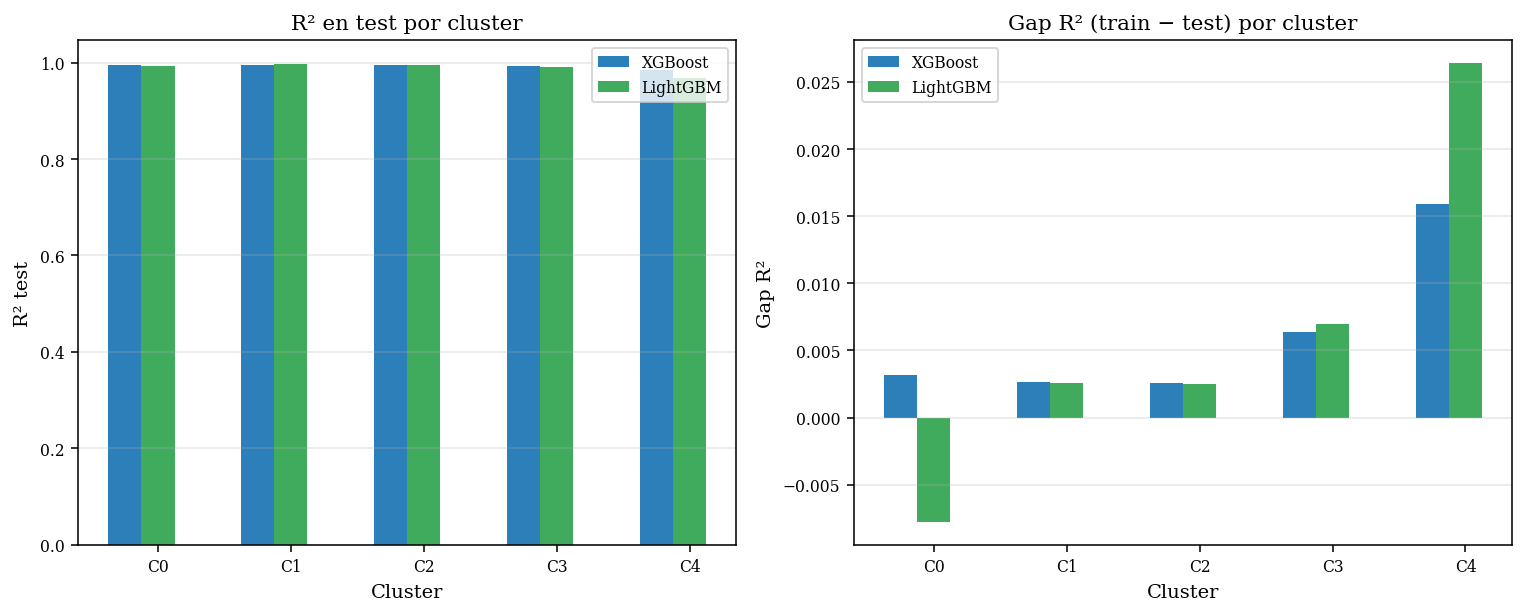

In [19]:
dm = df_mejores.to_pandas()
modelos_orden = ["XGBoost", "LightGBM"]
colores = {"XGBoost": "#2c7fb8", "LightGBM": "#41ab5d"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
clusters_plot = sorted(dm["cluster"].unique())
x = np.arange(len(clusters_plot)); w = 0.25

for j, tipo in enumerate(modelos_orden):
    r2 = [dm[(dm.cluster==c) & (dm.modelo==tipo)]["r2_test"].values[0]
          if not dm[(dm.cluster==c) & (dm.modelo==tipo)].empty else np.nan
          for c in clusters_plot]
    gap = [dm[(dm.cluster==c) & (dm.modelo==tipo)]["gap_r2_train_test"].values[0]
           if not dm[(dm.cluster==c) & (dm.modelo==tipo)].empty else np.nan
           for c in clusters_plot]
    axes[0].bar(x + (j-1)*w, r2, w, label=tipo, color=colores[tipo])
    axes[1].bar(x + (j-1)*w, gap, w, label=tipo, color=colores[tipo])

axes[0].set_title("R² en test por cluster"); axes[0].set_ylabel("R² test")
axes[1].set_title("Gap R² (train − test) por cluster"); axes[1].set_ylabel("Gap R²")
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels([f"C{c}" for c in clusters_plot])
    ax.set_xlabel("Cluster"); ax.legend(); ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
guardar_figura(fig, "comparacion_modelos_por_cluster")
plt.show()

## Selección del mejor modelo por cluster

Por defecto se elige, para cada cluster, la combinación con menor WMAPE de validación cruzada
entre los tres modelos. Puedes cambiar esta decisión editando el diccionario `eleccion`: basta
con indicar el modelo que prefieras para cada cluster según lo que veas en la grilla.

## Selección del mejor modelo por cluster

Por defecto se elige, para cada cluster, la combinación con menor WMAPE de validación cruzada
entre los tres modelos. Puedes cambiar esta decisión editando el diccionario `eleccion`: basta
con indicar el modelo que prefieras para cada cluster según lo que veas en la grilla.

In [20]:
# Elección MANUAL de modelo por cluster (trials que seleccionaste)
# Formato: cluster -> (tipo_modelo, numero_trial)
eleccion = {
    0: ("XGBoost", 9),   # Montaña: mejor gap y consistencia
    1: ("XGBoost", 7),    # Templada húmeda
    2: ("XGBoost", 15),   # Valle arenoso: menor gap sobre menor error
    3: ("XGBoost", 17),    # Valle arcilloso: mejor test + menor gap
    4: ("XGBoost", 19),    # Desierto: WMAPE plano, más regularizado
}
print("Elección de modelos por cluster:")
for c, (tipo, tr) in eleccion.items():
    print(f"  Cluster {c} ({etiquetas_cluster[c]}): {tipo} trial {tr}")

Elección de modelos por cluster:
  Cluster 0 (Montaña / clima frío): XGBoost trial 9
  Cluster 1 (Zona templada húmeda): XGBoost trial 7
  Cluster 2 (Valle cálido — suelo arenoso): XGBoost trial 15
  Cluster 3 (Valle cálido — suelo arcilloso): XGBoost trial 17
  Cluster 4 (Desierto árido): XGBoost trial 19


In [21]:
# Recuperar los hiperparámetros de cada trial elegido desde df_grid
# (las columnas param_* del registro de la grilla)
def recuperar_params(df_grid, cluster, tipo, trial):
    fila = df_grid.filter(
        (pl.col("cluster") == cluster) &
        (pl.col("modelo") == tipo) &
        (pl.col("trial") == trial)
    )
    if fila.height == 0:
        raise ValueError(f"No se encontró cluster={cluster}, {tipo}, trial={trial}")
    fila = fila.to_dicts()[0]
    params = {
        k.replace("param_", ""): v
        for k, v in fila.items()
        if k.startswith("param_") and v is not None
    }
    return params

# Construir el diccionario de params para cada elección
registro_params = {}
for c, (tipo, tr) in eleccion.items():
    registro_params[(c, tipo, tr)] = recuperar_params(df_grid, c, tipo, tr)
    print(f"Cluster {c}: {registro_params[(c, tipo, tr)]}")

Cluster 0: {'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8249370306839571, 'colsample_bytree': 0.873270852717686, 'reg_alpha': 0.0017364446910366974, 'reg_lambda': 0.6874540360805199, 'min_child_weight': 1, 'random_state': 42, 'n_jobs': -1, 'early_stopping_rounds': 30}
Cluster 1: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.9282665101082447, 'colsample_bytree': 0.8388643808853506, 'reg_alpha': 0.1279668772653042, 'reg_lambda': 0.0032308948770283508, 'min_child_weight': 14, 'random_state': 42, 'n_jobs': -1, 'early_stopping_rounds': 30}
Cluster 2: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.828236149860162, 'colsample_bytree': 0.7480068087968428, 'reg_alpha': 0.004857097503932088, 'reg_lambda': 0.022603954184260314, 'min_child_weight': 20, 'random_state': 42, 'n_jobs': -1, 'early_stopping_rounds': 30}
Cluster 3: {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.1, 'subsample': 0.8322425861236

In [22]:
from sklearn.metrics import r2_score, mean_squared_error

modelos_finales = {}
resultados_finales = []

for c, (tipo, tr) in eleccion.items():
    datos = datos_cluster[c]
    params = registro_params[(c, tipo, tr)]

    # Entrenar
    t0 = time.time()
    modelo = construir_modelo(tipo, params)
    modelo = ajustar_modelo(tipo, modelo, datos["X_tr"], datos["y_tr"],
                            datos["X_v"], datos["y_v"])
    t_entren = time.time() - t0

    # Métricas en los tres conjuntos
    m_tr = calcular_metricas(datos["y_tr"], modelo.predict(datos["X_tr"]))
    m_v  = calcular_metricas(datos["y_v"],  modelo.predict(datos["X_v"]))
    m_te = calcular_metricas(datos["y_te"], modelo.predict(datos["X_te"]))

    resultados_finales.append({
        "cluster": c,
        "etiqueta": etiquetas_cluster.get(c, c),
        "modelo": tipo, "trial": tr,
        "n_test": len(datos["y_te"]),
        "r2_train": m_tr["r2"], "r2_val": m_v["r2"], "r2_test": m_te["r2"],
        "wmape_train": m_tr["wmape"], "wmape_val": m_v["wmape"], "wmape_test": m_te["wmape"],
        "t_entrenamiento_s": round(t_entren, 2),
    })
    modelos_finales[c] = {"modelo": modelo, "tipo": tipo, "trial": tr}
    print(f"Cluster {c} ({etiquetas_cluster[c]}): "
          f"R² test = {m_te['r2']:.4f} | WMAPE test = {m_te['wmape']:.2f}%")

df_finales = pl.DataFrame(resultados_finales)
print("\nResumen de modelos finales:")
df_finales

Cluster 0 (Montaña / clima frío): R² test = 0.9948 | WMAPE test = 0.65%
Cluster 1 (Zona templada húmeda): R² test = 0.9943 | WMAPE test = 0.59%
Cluster 2 (Valle cálido — suelo arenoso): R² test = 0.9944 | WMAPE test = 0.60%
Cluster 3 (Valle cálido — suelo arcilloso): R² test = 0.9930 | WMAPE test = 0.48%
Cluster 4 (Desierto árido): R² test = 0.9877 | WMAPE test = 0.36%

Resumen de modelos finales:


cluster,etiqueta,modelo,trial,n_test,r2_train,r2_val,r2_test,wmape_train,wmape_val,wmape_test,t_entrenamiento_s
i64,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64
0,"""Montaña / clima frío""","""XGBoost""",9,9855,0.998006,0.990702,0.994836,0.224409,0.47653,0.649075,1.54
1,"""Zona templada húmeda""","""XGBoost""",7,27764,0.996998,0.994335,0.994334,0.422581,0.607004,0.591196,3.3
2,"""Valle cálido — suelo arenoso""","""XGBoost""",15,41032,0.996763,0.978509,0.994431,0.467293,0.908362,0.598337,5.42
3,"""Valle cálido — suelo arcilloso""","""XGBoost""",17,37261,0.999407,0.99765,0.993022,0.169642,0.457278,0.477929,8.71
4,"""Desierto árido""","""XGBoost""",19,2743,0.999968,0.994988,0.987728,0.071834,0.37191,0.362713,2.14


In [23]:
# ══════════════════════════════════════════════════════
#  MÉTRICA GLOBAL AGREGADA
#  Junta las predicciones de los 5 modelos sobre el test
#  de cada cluster, y calcula la métrica sobre todo el
#  territorio. Es el número comparable con el modelo único.
# ══════════════════════════════════════════════════════
y_all, pred_all = [], []
for c in modelos_finales:
    datos = datos_cluster[c]
    y_all.append(datos["y_te"])
    pred_all.append(modelos_finales[c]["modelo"].predict(datos["X_te"]))

y_all = np.concatenate(y_all)
pred_all = np.concatenate(pred_all)

r2_agregado    = r2_score(y_all, pred_all)
wmape_agregado = wmape(y_all, pred_all)
rmse_agregado  = np.sqrt(mean_squared_error(y_all, pred_all))

print("="*55)
print("  ENFOQUE POR CLUSTER — métrica global agregada")
print("="*55)
print(f"  R²:    {r2_agregado:.4f}")
print(f"  WMAPE: {wmape_agregado:.2f}%")
print(f"  RMSE:  {rmse_agregado:.4f}")
print(f"  Observaciones test totales: {len(y_all):,}")
print("="*55)

# Comparación con el modelo global único
print("\n  COMPARACIÓN:")
print(f"  Modelo único (global):     R² test ≈ 0,482")
print(f"  Modelos por cluster:       R² test = {r2_agregado:.4f}")
print(f"  Mejora:                    +{r2_agregado - 0.482:.4f}")

  ENFOQUE POR CLUSTER — métrica global agregada
  R²:    0.9957
  WMAPE: 0.56%
  RMSE:  0.0060
  Observaciones test totales: 118,655

  COMPARACIÓN:
  Modelo único (global):     R² test ≈ 0,482
  Modelos por cluster:       R² test = 0.9957
  Mejora:                    +0.5137


In [24]:
import joblib
import json
import os

# Carpeta específica para no sobrescribir otros modelos
XGB_DIR = os.path.join(MODELS_DIR, "xgboost_final")
os.makedirs(XGB_DIR, exist_ok=True)

for c, info in modelos_finales.items():
    tipo = info["tipo"]
    trial = info["trial"]
    params = registro_params[(c, tipo, trial)]
    features = datos_cluster[c]["features"]

    # 1. El modelo entrenado
    joblib.dump(info["modelo"], os.path.join(XGB_DIR, f"modelo_cluster_{c}_xgb.pkl"))

    # 2. La lista de features (orden de columnas, imprescindible para predecir)
    with open(os.path.join(XGB_DIR, f"features_cluster_{c}.json"), "w") as f:
        json.dump(features, f, indent=2)

    # 3. Metadatos: tipo, trial, hiperparámetros y métricas
    meta = {
        "cluster": c,
        "etiqueta": etiquetas_cluster.get(c, str(c)),
        "tipo": tipo,
        "trial": trial,
        "params": {k: (list(v) if isinstance(v, tuple) else v)
                   for k, v in params.items()},
    }
    with open(os.path.join(XGB_DIR, f"meta_cluster_{c}.json"), "w") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    print(f"Cluster {c} ({etiquetas_cluster[c]}): guardado modelo + features + meta")

print(f"\nTodo guardado en: {XGB_DIR}")

Cluster 0 (Montaña / clima frío): guardado modelo + features + meta
Cluster 1 (Zona templada húmeda): guardado modelo + features + meta
Cluster 2 (Valle cálido — suelo arenoso): guardado modelo + features + meta
Cluster 3 (Valle cálido — suelo arcilloso): guardado modelo + features + meta
Cluster 4 (Desierto árido): guardado modelo + features + meta

Todo guardado en: ../models/xgboost_final


## Elegidos LightGBM

In [25]:
# Elección MANUAL de LightGBM por cluster
# Formato: cluster -> (tipo_modelo, numero_trial)
eleccion_lgb = {
    0: ("LightGBM", 0),   # Montaña: único candidato, gap 0
    1: ("LightGBM", 12),   # Templada: mejor test y WMAPE
    2: ("LightGBM", 16),    # Valle arenoso: mejor test y WMAPE
    3: ("LightGBM", 15),    # Valle arcilloso: más consistente (cambia a 10 si prefieres test)
    4: ("LightGBM", 4),    # Desierto: WMAPE 0.71, el mejor
}
print("Elección de modelos LightGBM por cluster:")
for c, (tipo, tr) in eleccion_lgb.items():
    print(f"  Cluster {c} ({etiquetas_cluster[c]}): {tipo} trial {tr}")

Elección de modelos LightGBM por cluster:
  Cluster 0 (Montaña / clima frío): LightGBM trial 0
  Cluster 1 (Zona templada húmeda): LightGBM trial 12
  Cluster 2 (Valle cálido — suelo arenoso): LightGBM trial 16
  Cluster 3 (Valle cálido — suelo arcilloso): LightGBM trial 15
  Cluster 4 (Desierto árido): LightGBM trial 4


In [26]:
# Recuperar params desde df_grid para las elecciones de LightGBM
registro_params_lgb = {}
for c, (tipo, tr) in eleccion_lgb.items():
    registro_params_lgb[(c, tipo, tr)] = recuperar_params(df_grid, c, tipo, tr)

# Entrenar los modelos finales de LightGBM
modelos_finales_lgb = {}
resultados_finales_lgb = []

for c, (tipo, tr) in eleccion_lgb.items():
    datos = datos_cluster[c]
    params = registro_params_lgb[(c, tipo, tr)]

    modelo = construir_modelo(tipo, params)
    modelo = ajustar_modelo(tipo, modelo, datos["X_tr"], datos["y_tr"],
                            datos["X_v"], datos["y_v"])

    m_tr = calcular_metricas(datos["y_tr"], modelo.predict(datos["X_tr"]))
    m_v  = calcular_metricas(datos["y_v"],  modelo.predict(datos["X_v"]))
    m_te = calcular_metricas(datos["y_te"], modelo.predict(datos["X_te"]))

    resultados_finales_lgb.append({
        "cluster": c, "etiqueta": etiquetas_cluster.get(c, c),
        "modelo": tipo, "trial": tr,
        "r2_train": m_tr["r2"], "r2_val": m_v["r2"], "r2_test": m_te["r2"],
        "wmape_train": m_tr["wmape"], "wmape_val": m_v["wmape"], "wmape_test": m_te["wmape"],
    })
    modelos_finales_lgb[c] = {"modelo": modelo, "tipo": tipo, "trial": tr}
    print(f"Cluster {c} ({etiquetas_cluster[c]}): "
          f"R² test = {m_te['r2']:.4f} | WMAPE test = {m_te['wmape']:.2f}%")

df_finales_lgb = pl.DataFrame(resultados_finales_lgb)
df_finales_lgb

Cluster 0 (Montaña / clima frío): R² test = 0.9861 | WMAPE test = 1.14%
Cluster 1 (Zona templada húmeda): R² test = 0.9966 | WMAPE test = 0.44%
Cluster 2 (Valle cálido — suelo arenoso): R² test = 0.9960 | WMAPE test = 0.48%
Cluster 3 (Valle cálido — suelo arcilloso): R² test = 0.9930 | WMAPE test = 0.46%
Cluster 4 (Desierto árido): R² test = 0.9698 | WMAPE test = 0.55%


cluster,etiqueta,modelo,trial,r2_train,r2_val,r2_test,wmape_train,wmape_val,wmape_test
i64,str,str,i64,f64,f64,f64,f64,f64,f64
0,"""Montaña / clima frío""","""LightGBM""",0,0.985738,0.97844,0.98613,0.4001,0.766484,1.142589
1,"""Zona templada húmeda""","""LightGBM""",12,0.998516,0.995516,0.996583,0.277329,0.513707,0.43842
2,"""Valle cálido — suelo arenoso""","""LightGBM""",16,0.998022,0.98064,0.995996,0.312659,0.795544,0.48494
3,"""Valle cálido — suelo arcilloso""","""LightGBM""",15,0.999221,0.99742,0.992962,0.196534,0.498069,0.461304
4,"""Desierto árido""","""LightGBM""",4,0.999621,0.981736,0.969771,0.105299,0.546345,0.549768


In [ ]:
y_all, pred_all = [], []
for c in modelos_finales_lgb:
    datos = datos_cluster[c]
    y_all.append(datos["y_te"])
    pred_all.append(modelos_finales_lgb[c]["modelo"].predict(datos["X_te"]))

y_all = np.concatenate(y_all)
pred_all = np.concatenate(pred_all)

r2_lgb    = r2_score(y_all, pred_all)
wmape_lgb = wmape(y_all, pred_all)

print("="*55)
print("  LightGBM POR CLUSTER — métrica global agregada")
print("="*55)
print(f"  R²:    {r2_lgb:.4f}")
print(f"  WMAPE: {wmape_lgb:.2f}%")
print("="*55)
print(f"\n  COMPARACIÓN de enfoques por cluster:")
print(f"  XGBoost:   R² = {r2_agregado:.4f}")
print(f"  LightGBM:  R² = {r2_lgb:.4f}")

  LightGBM POR CLUSTER — métrica global agregada
  R²:    0.9955
  WMAPE: 0.52%

  COMPARACIÓN de enfoques por cluster:
  XGBoost:   R² = 0,960
  LightGBM:  R² = 0.9955


In [28]:
import joblib
import json
import os

# Carpeta específica para LightGBM (separada de XGBoost)
LGB_DIR = os.path.join(MODELS_DIR, "lightgbm_final")
os.makedirs(LGB_DIR, exist_ok=True)

for c, info in modelos_finales_lgb.items():
    tipo = info["tipo"]
    trial = info["trial"]
    params = registro_params_lgb[(c, tipo, trial)]
    features = datos_cluster[c]["features"]

    # 1. El modelo entrenado
    joblib.dump(info["modelo"], os.path.join(LGB_DIR, f"modelo_cluster_{c}_lgb.pkl"))

    # 2. La lista de features (orden de columnas, imprescindible para predecir)
    with open(os.path.join(LGB_DIR, f"features_cluster_{c}.json"), "w") as f:
        json.dump(features, f, indent=2)

    # 3. Metadatos: tipo, trial e hiperparámetros
    meta = {
        "cluster": c,
        "etiqueta": etiquetas_cluster.get(c, str(c)),
        "tipo": tipo,
        "trial": trial,
        "params": {k: (list(v) if isinstance(v, tuple) else v)
                   for k, v in params.items()},
    }
    with open(os.path.join(LGB_DIR, f"meta_cluster_{c}.json"), "w") as f:
        json.dump(meta, f, indent=2, ensure_ascii=False)

    print(f"Cluster {c} ({etiquetas_cluster[c]}): guardado modelo + features + meta")

print(f"\nModelos finales LightGBM guardados en: {LGB_DIR}")

Cluster 0 (Montaña / clima frío): guardado modelo + features + meta
Cluster 1 (Zona templada húmeda): guardado modelo + features + meta
Cluster 2 (Valle cálido — suelo arenoso): guardado modelo + features + meta
Cluster 3 (Valle cálido — suelo arcilloso): guardado modelo + features + meta
Cluster 4 (Desierto árido): guardado modelo + features + meta

Modelos finales LightGBM guardados en: ../models/lightgbm_final


## Red Neuronal

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import copy, time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class RedIAI(nn.Module):
    """Red configurable: las capas ocultas se definen por parámetro."""
    def __init__(self, input_dim, hidden=(128, 64), dropout=0.2):
        super().__init__()
        capas = []
        prev = input_dim
        for h in hidden:
            capas += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        capas += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*capas)
    def forward(self, x):
        return self.net(x)

In [30]:
def entrenar_red_rapida(X_tr, y_tr, X_va, y_va, n_base, hidden, dropout, lr,
                        max_epochs=60, patience=8, seed=42):
    torch.manual_seed(seed)
    scaler = StandardScaler()
    X_tr_sc = X_tr.copy().astype('float32')
    X_va_sc = X_va.copy().astype('float32')
    X_tr_sc[:, :n_base] = scaler.fit_transform(X_tr[:, :n_base])
    X_va_sc[:, :n_base] = scaler.transform(X_va[:, :n_base])

    # batch grande = más rápido en GPU
    tr_loader = DataLoader(TensorDataset(
        torch.tensor(X_tr_sc), torch.tensor(y_tr, dtype=torch.float32).view(-1,1)),
        batch_size=4096, shuffle=True)

    X_va_t = torch.tensor(X_va_sc).to(device)
    y_va_t = torch.tensor(y_va, dtype=torch.float32).view(-1,1).to(device)

    modelo = RedIAI(X_tr_sc.shape[1], hidden, dropout).to(device)
    crit = nn.MSELoss()
    opt = optim.Adam(modelo.parameters(), lr=lr, weight_decay=1e-5)

    mejor, mejores_pesos, pc = float('inf'), None, 0
    for ep in range(max_epochs):
        modelo.train()
        for Xb, yb in tr_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(modelo(Xb), yb)
            loss.backward(); opt.step()
        modelo.eval()
        with torch.no_grad():
            vloss = crit(modelo(X_va_t), y_va_t).item()
        if vloss < mejor:
            mejor, mejores_pesos, pc = vloss, copy.deepcopy(modelo.state_dict()), 0
        else:
            pc += 1
        if pc >= patience:
            break
    modelo.load_state_dict(mejores_pesos)
    return modelo, scaler

def predecir_red(modelo, scaler, X, n_base):
    modelo.eval()
    X_sc = X.copy().astype('float32')
    X_sc[:, :n_base] = scaler.transform(X[:, :n_base])
    with torch.no_grad():
        return modelo(torch.tensor(X_sc).to(device)).cpu().numpy().ravel()

In [31]:
# Rejilla PEQUEÑA de arquitecturas (ligera para no tardar)
grid_nn_params = [
    {"hidden": (64, 32),      "dropout": 0.2, "lr": 0.001},
    {"hidden": (128, 64),     "dropout": 0.2, "lr": 0.001},
    {"hidden": (128, 64, 32), "dropout": 0.3, "lr": 0.001},
    {"hidden": (64, 32),      "dropout": 0.1, "lr": 0.005},
]

n_base = len(features_base)   # nº de columnas continuas a escalar
registro_nn = []

for c in clusters:
    datos = datos_cluster[c]
    print(f"\n=== Cluster {c} ({etiquetas_cluster[c]}) ===")
    for i, p in enumerate(grid_nn_params):
        t0 = time.time()
        modelo, scaler = entrenar_red_rapida(
            datos["X_tr"], datos["y_tr"], datos["X_v"], datos["y_v"],
            n_base, p["hidden"], p["dropout"], p["lr"])

        m_tr = calcular_metricas(datos["y_tr"], predecir_red(modelo, scaler, datos["X_tr"], n_base))
        m_v  = calcular_metricas(datos["y_v"],  predecir_red(modelo, scaler, datos["X_v"],  n_base))
        m_te = calcular_metricas(datos["y_te"], predecir_red(modelo, scaler, datos["X_te"], n_base))

        registro_nn.append({
            "cluster": c, "etiqueta": etiquetas_cluster.get(c, c),
            "modelo": "RedNeuronal", "trial": i,
            "hidden": str(p["hidden"]), "dropout": p["dropout"], "lr": p["lr"],
            "r2_train": m_tr["r2"], "r2_val": m_v["r2"], "r2_test": m_te["r2"],
            "wmape_train": m_tr["wmape"], "wmape_val": m_v["wmape"], "wmape_test": m_te["wmape"],
            "gap_r2_train_test": abs(m_tr["r2"] - m_te["r2"]),
            "gap_wmape_train_test": abs(m_tr["wmape"] - m_te["wmape"]),
            "t_s": round(time.time()-t0, 1),
        })
        print(f"  trial {i} {p['hidden']}: R² te={m_te['r2']:.3f} | WMAPE te={m_te['wmape']:.2f} | {registro_nn[-1]['t_s']}s")

df_grid_nn = pl.DataFrame(registro_nn)
df_grid_nn.write_excel("grid_clusters_red.xlsx")
print("\nGuardado: grid_clusters_red.xlsx")


=== Cluster 0 (Montaña / clima frío) ===
  trial 0 (64, 32): R² te=0.910 | WMAPE te=3.23 | 50.5s
  trial 1 (128, 64): R² te=0.834 | WMAPE te=4.07 | 20.6s
  trial 2 (128, 64, 32): R² te=0.733 | WMAPE te=5.70 | 20.5s
  trial 3 (64, 32): R² te=0.948 | WMAPE te=2.28 | 33.1s

=== Cluster 1 (Zona templada húmeda) ===
  trial 0 (64, 32): R² te=0.962 | WMAPE te=1.70 | 173.0s
  trial 1 (128, 64): R² te=0.950 | WMAPE te=1.83 | 172.8s
  trial 2 (128, 64, 32): R² te=0.955 | WMAPE te=1.76 | 207.3s
  trial 3 (64, 32): R² te=0.964 | WMAPE te=1.60 | 87.3s

=== Cluster 2 (Valle cálido — suelo arenoso) ===
  trial 0 (64, 32): R² te=0.955 | WMAPE te=1.43 | 291.0s
  trial 1 (128, 64): R² te=0.977 | WMAPE te=1.02 | 300.2s
  trial 2 (128, 64, 32): R² te=0.979 | WMAPE te=1.09 | 343.9s
  trial 3 (64, 32): R² te=0.983 | WMAPE te=0.89 | 289.8s

=== Cluster 3 (Valle cálido — suelo arcilloso) ===
  trial 0 (64, 32): R² te=0.966 | WMAPE te=1.31 | 281.1s
  trial 1 (128, 64): R² te=0.982 | WMAPE te=0.90 | 329.6s
  

## Elección de los mejores trials de la red por cluster

In [32]:
# Mejor trial de la red por cluster (según R² test y WMAPE)
eleccion_nn = {
    0: 3,   # Montaña:  
    1: 3,   # Templada:  
    2: 1,   # Arenoso:  
    3: 3,   # Arcilloso: 
    4: 3,   # Desierto:  
}

# Los params de cada arquitectura
grid_nn_params = [
    {"hidden": (64, 32),      "dropout": 0.2, "lr": 0.001},
    {"hidden": (128, 64),     "dropout": 0.2, "lr": 0.001},
    {"hidden": (128, 64, 32), "dropout": 0.3, "lr": 0.001},
    {"hidden": (64, 32),      "dropout": 0.1, "lr": 0.005},
]

print("Elección de red por cluster:")
for c, tr in eleccion_nn.items():
    p = grid_nn_params[tr]
    print(f"  Cluster {c} ({etiquetas_cluster[c]}): trial {tr} {p['hidden']}")

Elección de red por cluster:
  Cluster 0 (Montaña / clima frío): trial 3 (64, 32)
  Cluster 1 (Zona templada húmeda): trial 3 (64, 32)
  Cluster 2 (Valle cálido — suelo arenoso): trial 1 (128, 64)
  Cluster 3 (Valle cálido — suelo arcilloso): trial 3 (64, 32)
  Cluster 4 (Desierto árido): trial 3 (64, 32)


### Reentrenar los mejores y calcular el agregado

In [34]:
n_base = len(features_base)

modelos_finales_nn = {}
y_all, pred_all = [], []

for c, tr in eleccion_nn.items():
    datos = datos_cluster[c]
    p = grid_nn_params[tr]

    modelo, scaler = entrenar_red_rapida(
        datos["X_tr"], datos["y_tr"], datos["X_v"], datos["y_v"],
        n_base, p["hidden"], p["dropout"], p["lr"])

    pred_te = predecir_red(modelo, scaler, datos["X_te"], n_base)
    modelos_finales_nn[c] = {"modelo": modelo, "scaler": scaler, "trial": tr}

    y_all.append(datos["y_te"])
    pred_all.append(pred_te)

    m_te = calcular_metricas(datos["y_te"], pred_te)
    print(f"Cluster {c}: R² test = {m_te['r2']:.4f} | WMAPE test = {m_te['wmape']:.2f}%")

y_all = np.concatenate(y_all)
pred_all = np.concatenate(pred_all)

r2_nn    = r2_score(y_all, pred_all)
wmape_nn = wmape(y_all, pred_all)

print("\n" + "="*55)
print("  RED NEURONAL POR CLUSTER — métrica global agregada")
print("="*55)
print(f"  R²:    {r2_nn:.4f}")
print(f"  WMAPE: {wmape_nn:.2f}%")
print("="*55)


Cluster 0: R² test = 0.9484 | WMAPE test = 2.28%
Cluster 1: R² test = 0.9644 | WMAPE test = 1.60%
Cluster 2: R² test = 0.9770 | WMAPE test = 1.02%
Cluster 3: R² test = 0.9873 | WMAPE test = 0.68%
Cluster 4: R² test = 0.9617 | WMAPE test = 1.21%

  RED NEURONAL POR CLUSTER — métrica global agregada
  R²:    0.9790
  WMAPE: 1.18%


In [35]:
print(f"\n  COMPARACIÓN de las tres familias:")
print(f"  LightGBM:      R² = {r2_lgb:.4f} | WMAPE = {wmape_lgb:.2f}%")
print(f"  XGBoost:       R² = {r2_agregado:.4f} | WMAPE = {wmape_agregado:.2f}%")
print(f"  Red neuronal:  R² = {r2_nn:.4f} | WMAPE = {wmape_nn:.2f}%")


  COMPARACIÓN de las tres familias:
  LightGBM:      R² = 0.9955 | WMAPE = 0.52%
  XGBoost:       R² = 0.9957 | WMAPE = 0.56%
  Red neuronal:  R² = 0.9790 | WMAPE = 1.18%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

COL_TRAIN = "#4575b4"   # azul
COL_VAL   = "#fdae61"   # naranja
COL_TEST  = "#d73027"   # rojo

def grafico_estabilidad(df, cluster_id=None, filtrar_modelo=None,
                        ruta_salida="estabilidad_modelos.pdf"):
    """Dibuja train/val/test por configuración. Líneas cortas = modelos estables."""
    d = df
    if cluster_id is not None:
        d = d[d["cluster"] == cluster_id]
    if filtrar_modelo is not None:
        d = d[d["modelo"] == filtrar_modelo]
    d = d.reset_index(drop=True)
    x = np.arange(len(d))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

    # Panel R2
    for i in x:
        ax1.plot([i, i], [d["r2_train"].iloc[i], d["r2_test"].iloc[i]],
                 color="#cccccc", linewidth=1, zorder=1)
    ax1.scatter(x, d["r2_train"], color=COL_TRAIN, s=28, label="Train", zorder=3)
    ax1.scatter(x, d["r2_val"],   color=COL_VAL,   s=28, label="Validación", zorder=3)
    ax1.scatter(x, d["r2_test"],  color=COL_TEST,  s=28, label="Prueba", zorder=3)
    ax1.set_title("Coeficiente de determinación ($R^2$)", fontsize=11)
    ax1.set_xlabel("Configuración"); ax1.set_ylabel("$R^2$")
    ax1.legend(fontsize=8, loc="lower right"); ax1.grid(alpha=0.3)

    # Panel WMAPE
    for i in x:
        ax2.plot([i, i], [d["wmape_train"].iloc[i], d["wmape_test"].iloc[i]],
                 color="#cccccc", linewidth=1, zorder=1)
    ax2.scatter(x, d["wmape_train"], color=COL_TRAIN, s=28, label="Train", zorder=3)
    ax2.scatter(x, d["wmape_val"],   color=COL_VAL,   s=28, label="Validación", zorder=3)
    ax2.scatter(x, d["wmape_test"],  color=COL_TEST,  s=28, label="Prueba", zorder=3)
    ax2.set_title("Error porcentual (WMAPE)", fontsize=11)
    ax2.set_xlabel("Configuración"); ax2.set_ylabel("WMAPE (%)")
    ax2.legend(fontsize=8, loc="upper right"); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(ruta_salida, bbox_inches="tight")
    plt.savefig(ruta_salida.replace(".pdf", ".png"), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Guardado: {ruta_salida}")

In [38]:
# Ver qué claves tiene el diccionario de modelos
print("Claves de modelos_finales_lgb[3]:", modelos_finales_lgb[3].keys())

# Ver también qué hay en datos_cluster
print("Claves de datos_cluster[3]:", datos_cluster[3].keys())

Claves de modelos_finales_lgb[3]: dict_keys(['modelo', 'tipo', 'trial'])
Claves de datos_cluster[3]: dict_keys(['X_tr', 'y_tr', 'cond_tr', 'X_v', 'y_v', 'X_te', 'y_te', 'features', 'n_condados_tr'])


Cluster 3 | features: 22 | muestra: (2000, 22)


C:\Users\lesli\AppData\Local\Temp\ipykernel_5580\3961274374.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feats, show=True)


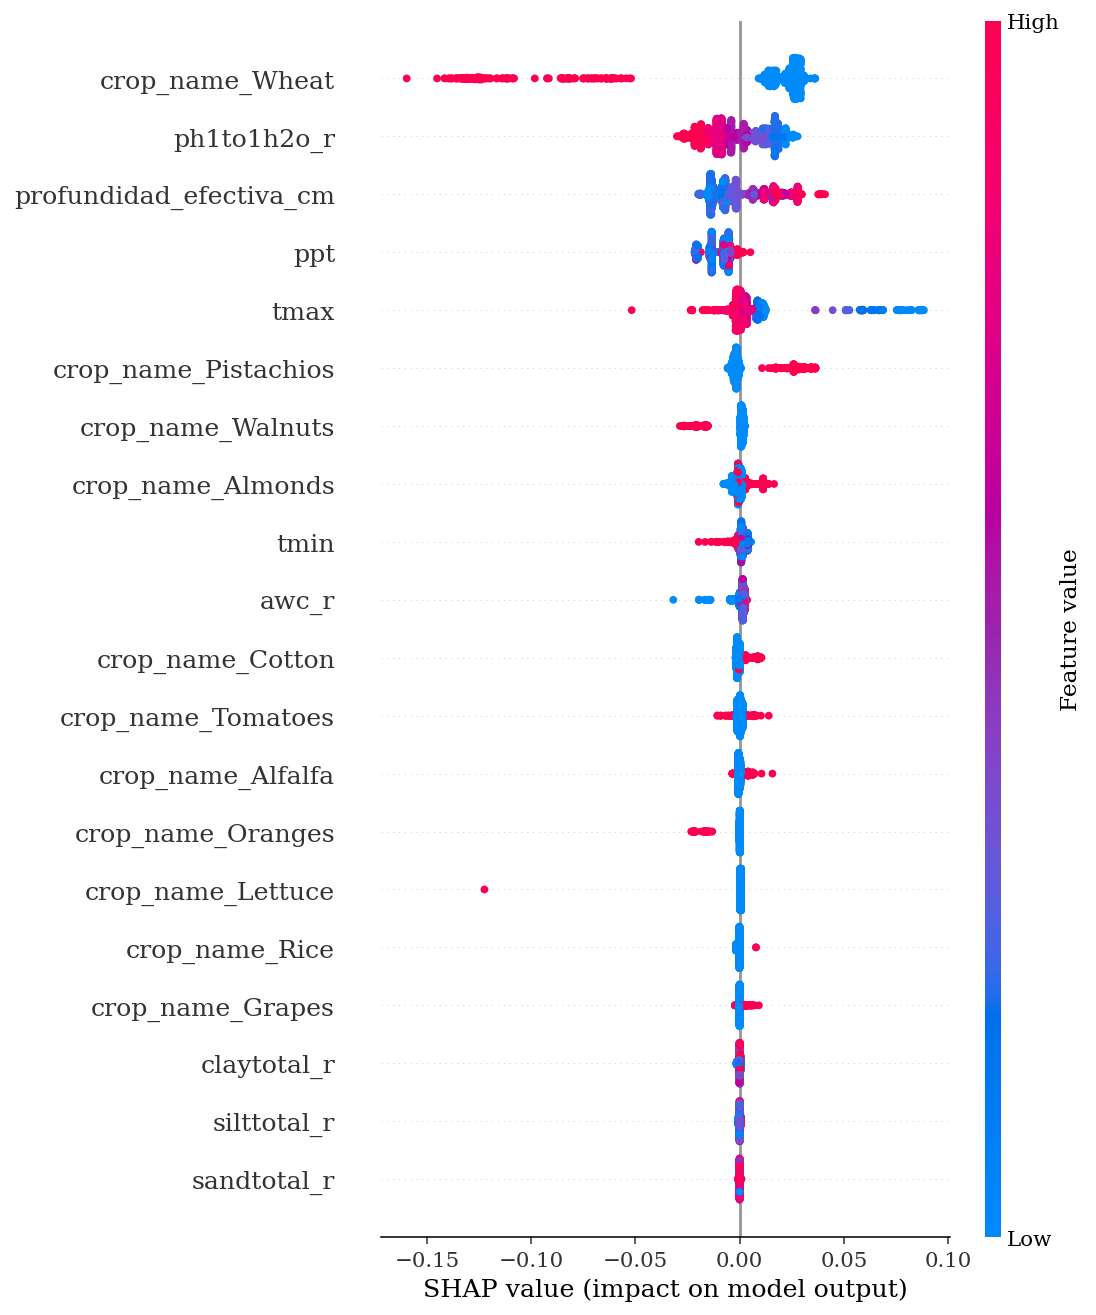

C:\Users\lesli\AppData\Local\Temp\ipykernel_5580\3961274374.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feats, show=False)


In [46]:
import shap

c = 3  # cluster con frutales (Valle arcilloso)
modelo = modelos_finales_lgb[c]["modelo"]
feats = datos_cluster[c]["features"]        # las features están AQUÍ

# Datos de test de ese cluster
X_sample = datos_cluster[c]["X_te"][:2000]

print(f"Cluster {c} | features: {len(feats)} | muestra: {X_sample.shape}")

# Calcular SHAP (TreeExplainer es rápido para LightGBM)
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

# 1. Summary plot: visión global de qué variables dominan
shap.summary_plot(shap_values, X_sample, feature_names=feats, show=True)

plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=feats, show=False)
plt.tight_layout()
plt.savefig("shap_summary_cluster3.png", dpi=300, bbox_inches="tight")
plt.close()

<Figure size 896x672 with 0 Axes>

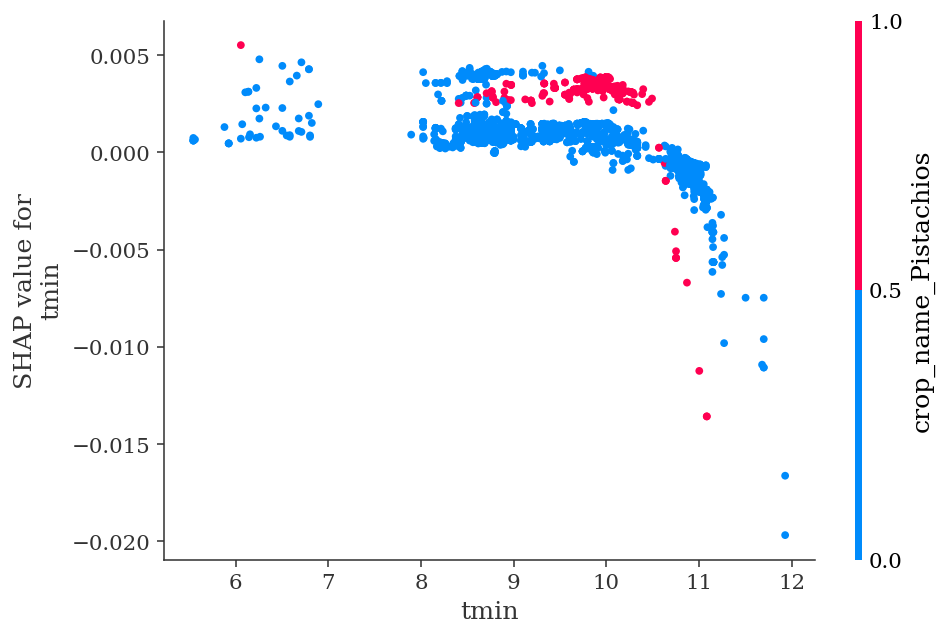

Guardado: shap_tmin_cluster3.png


In [47]:
# 2. Dependence plot de tmin (cómo usa el modelo la temperatura mínima)
idx_tmin = list(feats).index("tmin")
plt.figure()
shap.dependence_plot(idx_tmin, shap_values, X_sample, feature_names=feats, show=True)

plt.tight_layout()
plt.savefig("shap_tmin_cluster3.png", dpi=300, bbox_inches="tight")
plt.close()
print("Guardado: shap_tmin_cluster3.png")

Cluster 3 | features: 22 | muestra: (2000, 22)


C:\Users\lesli\AppData\Local\Temp\ipykernel_5580\1651149375.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feats, show=True)


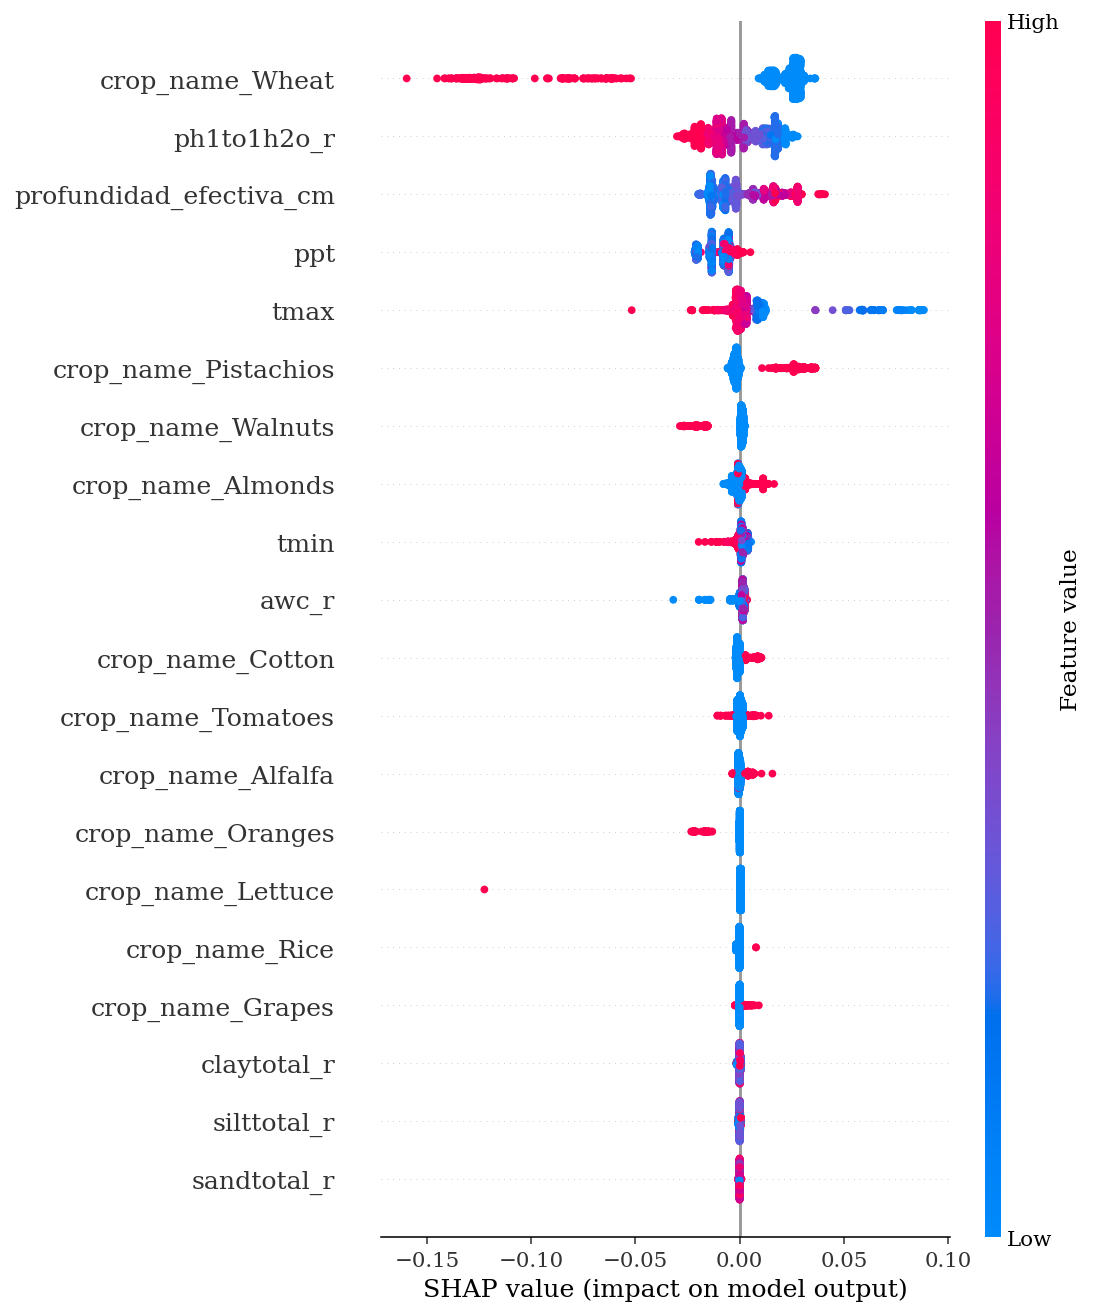

C:\Users\lesli\AppData\Local\Temp\ipykernel_5580\1651149375.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, feature_names=feats, show=False)


In [48]:
import shap

c = 3  # cluster con frutales (Valle arcilloso)
modelo = modelos_finales_lgb[c]["modelo"]
feats = datos_cluster[c]["features"]

# X_te ya es numpy, sin conversión
X_sample = datos_cluster[c]["X_te"][:2000]

print(f"Cluster {c} | features: {len(feats)} | muestra: {X_sample.shape}")

# Calcular SHAP
explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_sample)

# 1. Summary plot
shap.summary_plot(shap_values, X_sample, feature_names=feats, show=True)

# Versión PDF vectorial (recomendada para LaTeX)
plt.figure()
shap.summary_plot(shap_values, X_sample, feature_names=feats, show=False)
plt.tight_layout()
plt.savefig("shap_summary_cluster3.pdf", bbox_inches="tight")
plt.close()

In [49]:
# Dependence plot coloreado explícitamente por pistachos
idx_tmin = list(feats).index("tmin")
idx_pist = list(feats).index("crop_name_Pistachios")
plt.figure()
shap.dependence_plot(idx_tmin, shap_values, X_sample,
                     feature_names=feats,
                     interaction_index=idx_pist,  # colorea por pistachos
                     show=False)
plt.tight_layout()
plt.savefig("shap_tmin_pistachos.pdf", bbox_inches="tight")
plt.close()

<Figure size 896x672 with 0 Axes>

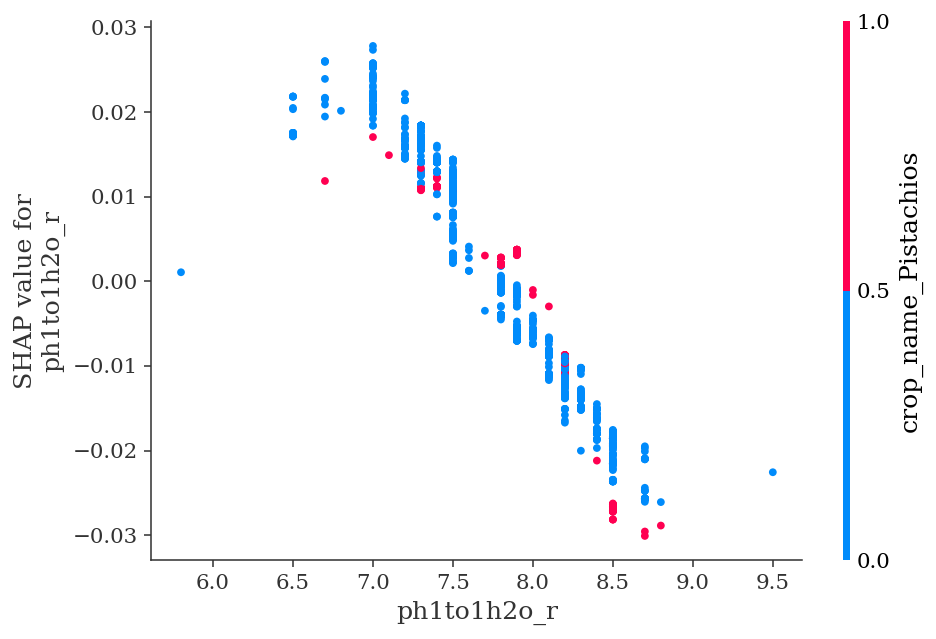

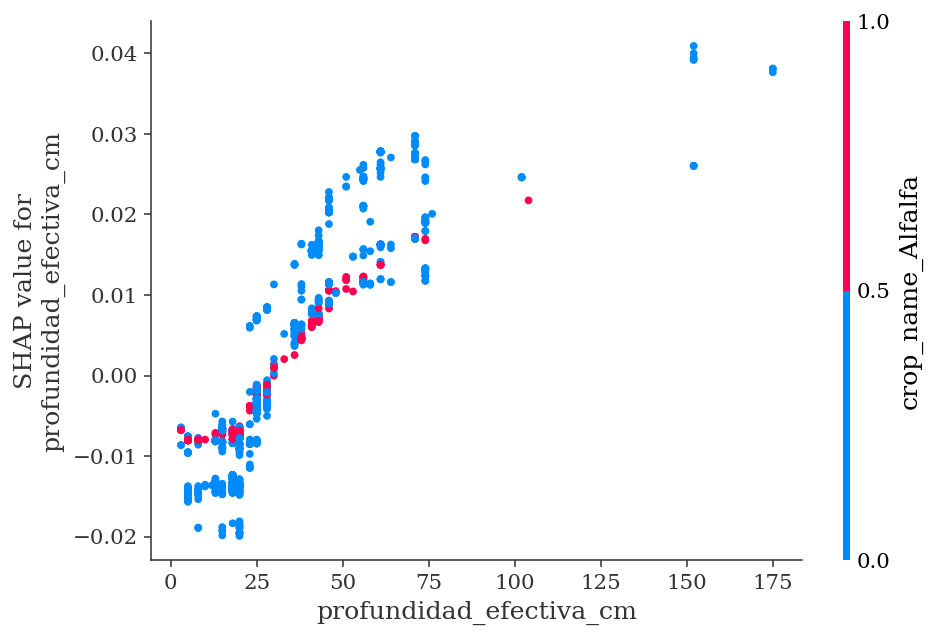

In [50]:
# Verificar la dirección del efecto del pH y la profundidad
for var in ["ph1to1h2o_r", "profundidad_efectiva_cm"]:
    idx = list(feats).index(var)
    shap.dependence_plot(idx, shap_values, X_sample, feature_names=feats, show=True)